# Exercício:

## 01 – Do exercício 2 da aula 15, exporte o objeto DataFrame contendo as frequências absolutas de cada aminoácido em cada proteína para .csv, instancie um objeto da classe DataFrame. Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas de tendência central. Qual o valor de média, mediana e moda da Serina nos genes analisados? E do terceiro gene?

In [2]:
import pandas as pd
df_final = pd.read_csv('df_final.csv', index_col=0, header=0)
print(df_final)

           A   C    D    E   F    G   H   I   K    L   M   N    P   Q    R  \
ID_gene                                                                      
HDAC1    271  70  106  175  75  180  56  32  75  178  16  46  197  73  187   
HDAC2     61  11   45   38  24   60  18  16  14   49  12  18   42  17   42   
HDAC3     38   9   38   20  24   34  21  21  21   35  10  19   24  12   20   
HDAC4     95  29   36   37  38   69  38  18  20   83   2  20   91  21   65   
HDAC5    184  60   77   90  46  140  44  38  41  125  19  34   87  44  112   

           S    T    V   W   Y  
ID_gene                         
HDAC1    333  114  141  13  25  
HDAC2     64   19   44   6  24  
HDAC3     28   14   34   2  27  
HDAC4    131   55   64   8  11  
HDAC5    129   67   83  16  16  


In [8]:
def tendencia_central(vetor):
    media = vetor.mean()
    mediana = vetor.median()
    moda = vetor.mode()
    
    return {
        "media": media,
        "mediana": mediana,
        "moda": moda.values
    }

resultado_serina = tendencia_central(df_final["S"])
print ("Resultado Serina:", resultado_serina)

gene_HDAC3 = df_final.iloc[2]
resultado_HDAC3 = tendencia_central(gene_HDAC3)
print ("Resultado HDAC3:",resultado_HDAC3)

Resultado Serina: {'media': np.float64(137.0), 'mediana': np.float64(129.0), 'moda': array([ 28,  64, 129, 131, 333])}
Resultado HDAC3: {'media': np.float64(22.55), 'mediana': np.float64(21.0), 'moda': array([21])}


## 02 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a amplitude. Qual o valor de amplitude da Isoleucina? E do último gene?

In [13]:
def amplitude(vetor):
    return vetor.max() - vetor.min()
amp_Iso = amplitude(df_final["I"])
print("Amplitude da Isoleucina:", amp_Iso)

ultimo_HDAC5 = df_final.iloc[-1]

amp_HDAC5 = amplitude(ultimo_HDAC5)
print("Amplitude do último gene (HDAC5):", amp_HDAC5)

Amplitude da Isoleucina: 22
Amplitude do último gene (HDAC5): 168


## 03 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne os quartis. Qual o valor do Q1, Q2 e Q3 da Metionina? E do primeiro gene?

In [14]:
def quartis(vetor):
    return {
        "Q1": vetor.quantile(0.25),
        "Q2": vetor.quantile(0.50),  # mediana
        "Q3": vetor.quantile(0.75)
    }
quart_metionina = quartis(df_final["M"])
print("Quartis de Metionina:", quart_metionina)

primeiro_HDAC1 = df_final.iloc[0]

quart_gene = quartis(primeiro_HDAC1)
print("Quartis do gene HDAC1:", quart_gene)

Quartis de Metionina: {'Q1': np.float64(10.0), 'Q2': np.float64(12.0), 'Q3': np.float64(16.0)}
Quartis do gene HDAC1: {'Q1': np.float64(53.5), 'Q2': np.float64(90.5), 'Q3': np.float64(178.5)}


## 04 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o intervalo interquartil. Qual o valor do o intervalo interquartil da Ácido Glutâmico? E do penúltimo gene? Obtenha o box plot com as medidas de tendência central para a frequência de aa nesse gene.

In [15]:
def iqr(vetor):
    q1 = vetor.quantile(0.25)
    q3 = vetor.quantile(0.75)
    return q3 - q1
iqr_E = iqr(df_final["E"])
print("IQR do ácido glutâmico:", iqr_E)

penultimo_HDAC4 = df_final.iloc[-2]

iqr_HDAC4 = iqr(penultimo_HDAC4)
print("IQR do gene HDAC4:", iqr_HDAC4)

IQR do ácido glutâmico: 53.0
IQR do gene HDAC4: 46.0


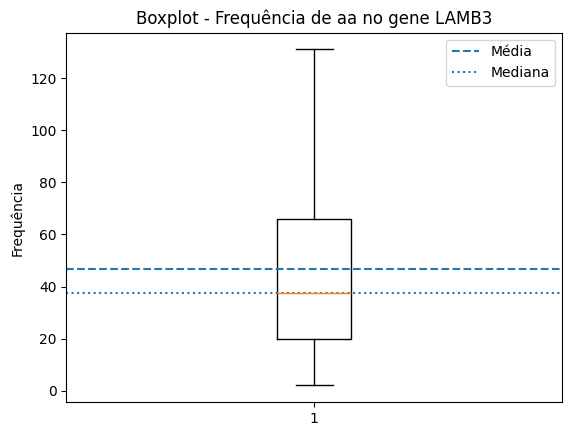

In [17]:
#boxplot
import matplotlib.pyplot as plt

valores = penultimo_HDAC4

media = valores.mean()
mediana = valores.median()

plt.boxplot(valores, vert=True)
plt.axhline(media, linestyle="--", label="Média")
plt.axhline(mediana, linestyle=":", label="Mediana")

plt.title("Boxplot - Frequência de aa no gene LAMB3")
plt.ylabel("Frequência")

plt.legend()
plt.show()

In [18]:
valores = df_final.iloc[-2].astype(float)

q1 = valores.quantile(0.25)
mediana = valores.quantile(0.50)
q3 = valores.quantile(0.75)
media = valores.mean()
minimo = valores.min()
maximo = valores.max()

print("Mínimo:", minimo)
print("Q1:", q1)
print("Mediana (Q2):", mediana)
print("Q3:", q3)
print("Máximo:", maximo)
print("Média:", media)
print("IQR:", q3 - q1)

Mínimo: 2.0
Q1: 20.0
Mediana (Q2): 37.5
Q3: 66.0
Máximo: 131.0
Média: 46.55
IQR: 46.0


## 05 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a variância amostral não viciada. Qual o valor da variância da Prolina? E do terceiro gene?

In [20]:
def variancia(vetor):
    return vetor.var(ddof=1)
var_Pro = variancia(df_final["P"])
print("Variância Prolina:", var_Pro)

terceiro_HDAC3 = df_final.iloc[2].astype(float)

var_HDAC3 = variancia(terceiro_HDAC3)
print("Variância do gene HDAC3:", var_HDAC3)

Variância Prolina: 4525.7
Variância do gene HDAC3: 101.52368421052631


## 06 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o desvio padrão. Qual o valor d o desvio padrão do Triptofano? E do gene de index -1?

In [21]:
def desvio_padrao(vetor):
    return vetor.std(ddof=1)
desvp_trip = desvio_padrao(df_final["W"])
print("Desvio padrão Triptofano:", desvp_trip)

gene_HDAC5 = df_final.iloc[-1].astype(float)

desvp_HDAC5 = desvio_padrao(gene_HDAC5)
print("Desvio padrão do gene HDAC5:", desvp_HDAC5)

Desvio padrão Triptofano: 5.5677643628300215
Desvio padrão do gene HDAC5: 46.20822437618654


## 07 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o coeficiente de variação. Qual o valor do coeficiente de variação da Leucina? E do gene de index 1?

In [22]:
def coef_variacao(vetor):
    media = vetor.mean()
    dp = vetor.std(ddof=1)
    return dp / media
cv_Leu = coef_variacao(df_final["L"])
print("Coeficiente de variação Leucina:", cv_Leu)

gene_HDAC2 = df_final.iloc[1].astype(float)

cv_HDAC2 = coef_variacao(gene_HDAC2)
print("Coeficiente de variação do gene HDAC2:", cv_HDAC2)

Coeficiente de variação Leucina: 0.6213166702318654
Coeficiente de variação do gene HDAC2: 0.5921480351038515


## 08 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas resumo.
Obs.: Use um dicionário onde os index são os nomes e os valores as medidas.

In [23]:
def medidas_resumo(vetor):
    media = float(vetor.mean())
    
    return {
        "media": round(media, 2),
        "mediana": round(float(vetor.median()), 2),
        "moda": vetor.mode().tolist(),
        "min": float(vetor.min()),
        "max": float(vetor.max()),
        "amplitude": float(vetor.max() - vetor.min()),
        "Q1": round(float(vetor.quantile(0.25)), 2),
        "Q2": round(float(vetor.quantile(0.50)), 2),
        "Q3": round(float(vetor.quantile(0.75)), 2),
        "IQR": round(float(vetor.quantile(0.75) - vetor.quantile(0.25)), 2),
        "variancia": round(float(vetor.var(ddof=1)), 2),
        "desvio_padrao": round(float(vetor.std(ddof=1)), 2),
        "coef_variacao": round(float(vetor.std(ddof=1) / media), 4)
    }
print("Serina:", medidas_resumo(df_final["S"]))

Serina: {'media': 137.0, 'mediana': 129.0, 'moda': [28, 64, 129, 131, 333], 'min': 28.0, 'max': 333.0, 'amplitude': 305.0, 'Q1': 64.0, 'Q2': 129.0, 'Q3': 131.0, 'IQR': 67.0, 'variancia': 13931.5, 'desvio_padrao': 118.03, 'coef_variacao': 0.8615}


## 09 – Defina uma função que retorne qual o gene com o maior CV de frequência de aminoácidos. Obtenha os boxplot dos genes. Os dados concordam? Porque?

In [32]:
def gene_maior_cv(df):
    cvs = df.apply(lambda linha: linha.std(ddof=1) / linha.mean(), axis=1)
    idx = cvs.idxmax()
    return idx, cvs[idx]
gene, valor = gene_maior_cv(df_final)

print("Gene com maior CV:", gene)
print("CV:", valor)

Gene com maior CV: HDAC1
CV: 0.7433224898026789


/var/folders/xn/fc5g_qrj2g5f3jmfn48499x80000gn/T/ipykernel_1951/319960473.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df_final.T, labels=df_final.index)


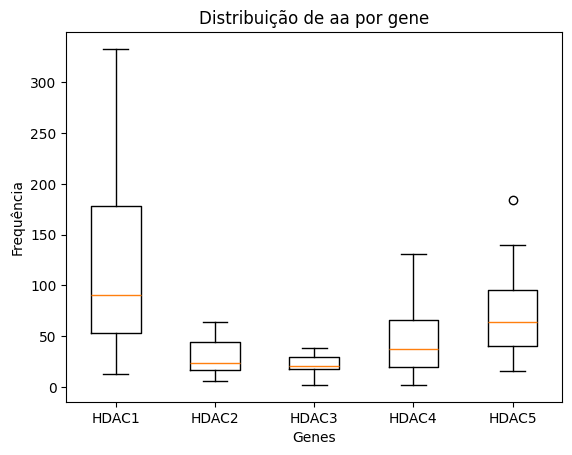

In [33]:
plt.boxplot(df_final.T, labels=df_final.index)

plt.title("Distribuição de aa por gene")
plt.xlabel("Genes")
plt.ylabel("Frequência")

plt.show()

R.: Sim — os dados fazem sentido com o que o boxplot mostra.

O coeficiente de variação (CV) mede a variabilidade relativa (desvio padrão dividido pela média). Então, quanto maior o CV, mais “espalhados” os dados estão em relação à média.

O gene HDAC1 possui grande dispersão dos dados centrais e distribuição bem mais espalhada que os outros genes. Isso indica alta variabilidade, concordando com o CV (~0,74).

E no caso do HDAC1, ele é o mais variável visualmente

## 10 – Defina uma função que retorne qual o aminoácidos com o maior CV dentre os genes. Obtenha os boxplot dos aminoácidos. Os dados concordam? Porque?

In [35]:
def aa_maior_cv(df):
    cvs = df.apply(lambda col: col.std(ddof=1) / col.mean(), axis=0)
    aa = cvs.idxmax()
    return aa, cvs[aa]
aa, valor = aa_maior_cv(df_final)

print("Aminoácido com maior CV:", aa)
print("CV:", valor)

Aminoácido com maior CV: E
CV: 0.8789044281531186


/var/folders/xn/fc5g_qrj2g5f3jmfn48499x80000gn/T/ipykernel_1951/585309812.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df_final, labels=df_final.columns)


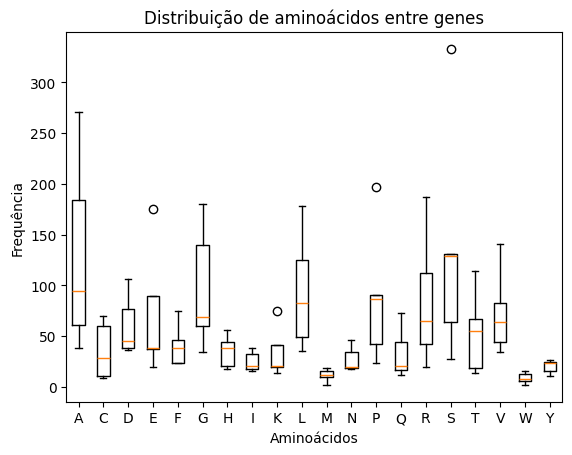

In [36]:
plt.boxplot(df_final, labels=df_final.columns)

plt.title("Distribuição de aminoácidos entre genes")
plt.xlabel("Aminoácidos")
plt.ylabel("Frequência")

plt.show()

R.: Visualmente os dados não parecem concordar, pois outros aminoácidos parecem com IQR alto. O aminoácido E apresenta variabilidade considerável no boxplot (caixa relativamente ampla e presença de outlier), e o CV alto (~0,88) indica grande dispersão em relação à média. Mesmo que outros aminoácidos pareçam mais espalhados visualmente, o CV do E pode ser maior porque sua média é mais baixa, o que aumenta o valor relativo da variação.